In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
N_SEGS = 12  # must match --n-segs used to build the LHS seed
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS, phase_max=True))
        except Exception:
            pass
    return out


def prior_transform(u):
    # logm1lim = [5.6,  6.4]
    # logm2lim = [0.8, 1.3]
    # alim = [0.3, 0.99]
    # p0lim = [8.0, 11.0]
    # e0lim = [0.2, 0.5]
    # qSlim = [0.0, np.pi]
    # phiSlim = [0.0, 2 * np.pi]
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    phiSlim = [0.0, 2 * np.pi]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6,  6.4]
    logm2lim = [1.7, 2.3]
    alim = [0.3, 0.99]
    p0lim = [13.5, 16.5]
    e0lim = [0.6, 0.9]
    cosqSlim = [-1.0, 1.0]      # cos(qS): source colatitude, sampled uniform in cosine
    phiSlim = [0.0, 2 * np.pi]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
print(parismc.__file__)

/nfs/home/svu/e1498138/parismc_dev/parismc/__init__.py


In [3]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage1_merge_s12_dev/'


In [4]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl', prior_transform=prior_transform, log_density_func=log_density)
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [5]:
sampler.now_covariances

[array([[ 9.28603910e-05,  2.30242463e-05,  3.02378469e-04,
         -4.65399521e-04, -2.87242213e-05, -2.29404295e-05,
         -1.28996813e-05],
        [ 2.30242463e-05,  7.22727285e-06,  7.39714768e-05,
         -1.12298503e-04, -8.04405460e-06, -8.00101999e-06,
          3.94182781e-06],
        [ 3.02378469e-04,  7.39714768e-05,  9.86859464e-04,
         -1.51949567e-03, -9.28901068e-05, -7.29127395e-05,
         -4.94178793e-05],
        [-4.65399521e-04, -1.12298503e-04, -1.51949567e-03,
          2.34311110e-03,  1.42664450e-04,  1.04796298e-04,
          7.91387944e-05],
        [-2.87242213e-05, -8.04405460e-06, -9.28901068e-05,
          1.42664450e-04,  9.99261111e-06,  5.92967205e-06,
         -1.86268343e-06],
        [-2.29404295e-05, -8.00101999e-06, -7.29127395e-05,
          1.04796298e-04,  5.92967205e-06,  1.74860538e-03,
          2.36342927e-04],
        [-1.28996813e-05,  3.94182781e-06, -4.94178793e-05,
          7.91387944e-05, -1.86268343e-06,  2.36342927e-04

In [6]:
len(sampler.now_covariances)

2

In [7]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.83423876,  1.99380873,  0.51982598, 15.57711103,  0.74333545,
         0.77934556,  3.39735454]])

In [8]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.80212668,  1.98886699,  0.42746621, 16.1955276 ,  0.74663322,
        -0.83734782,  0.42496134]])

In [10]:
log_density(maxld_pt1)

array([91.47916021])

In [11]:
log_density(maxld_pt2)

array([78.81278672])

In [12]:
log_density([param_true])

array([100.65186542])

In [13]:
param_ranges = [(5.6,6.4),
                (1.7,2.3),
                (0.3,0.99),
                (13.5,16.5),
                (0.6,0.9),
                (-1,1),
                (0.0, 2 * np.pi)
                ]
param_ranges

[(5.6, 6.4),
 (1.7, 2.3),
 (0.3, 0.99),
 (13.5, 16.5),
 (0.6, 0.9),
 (-1, 1),
 (0.0, 6.283185307179586)]

In [14]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

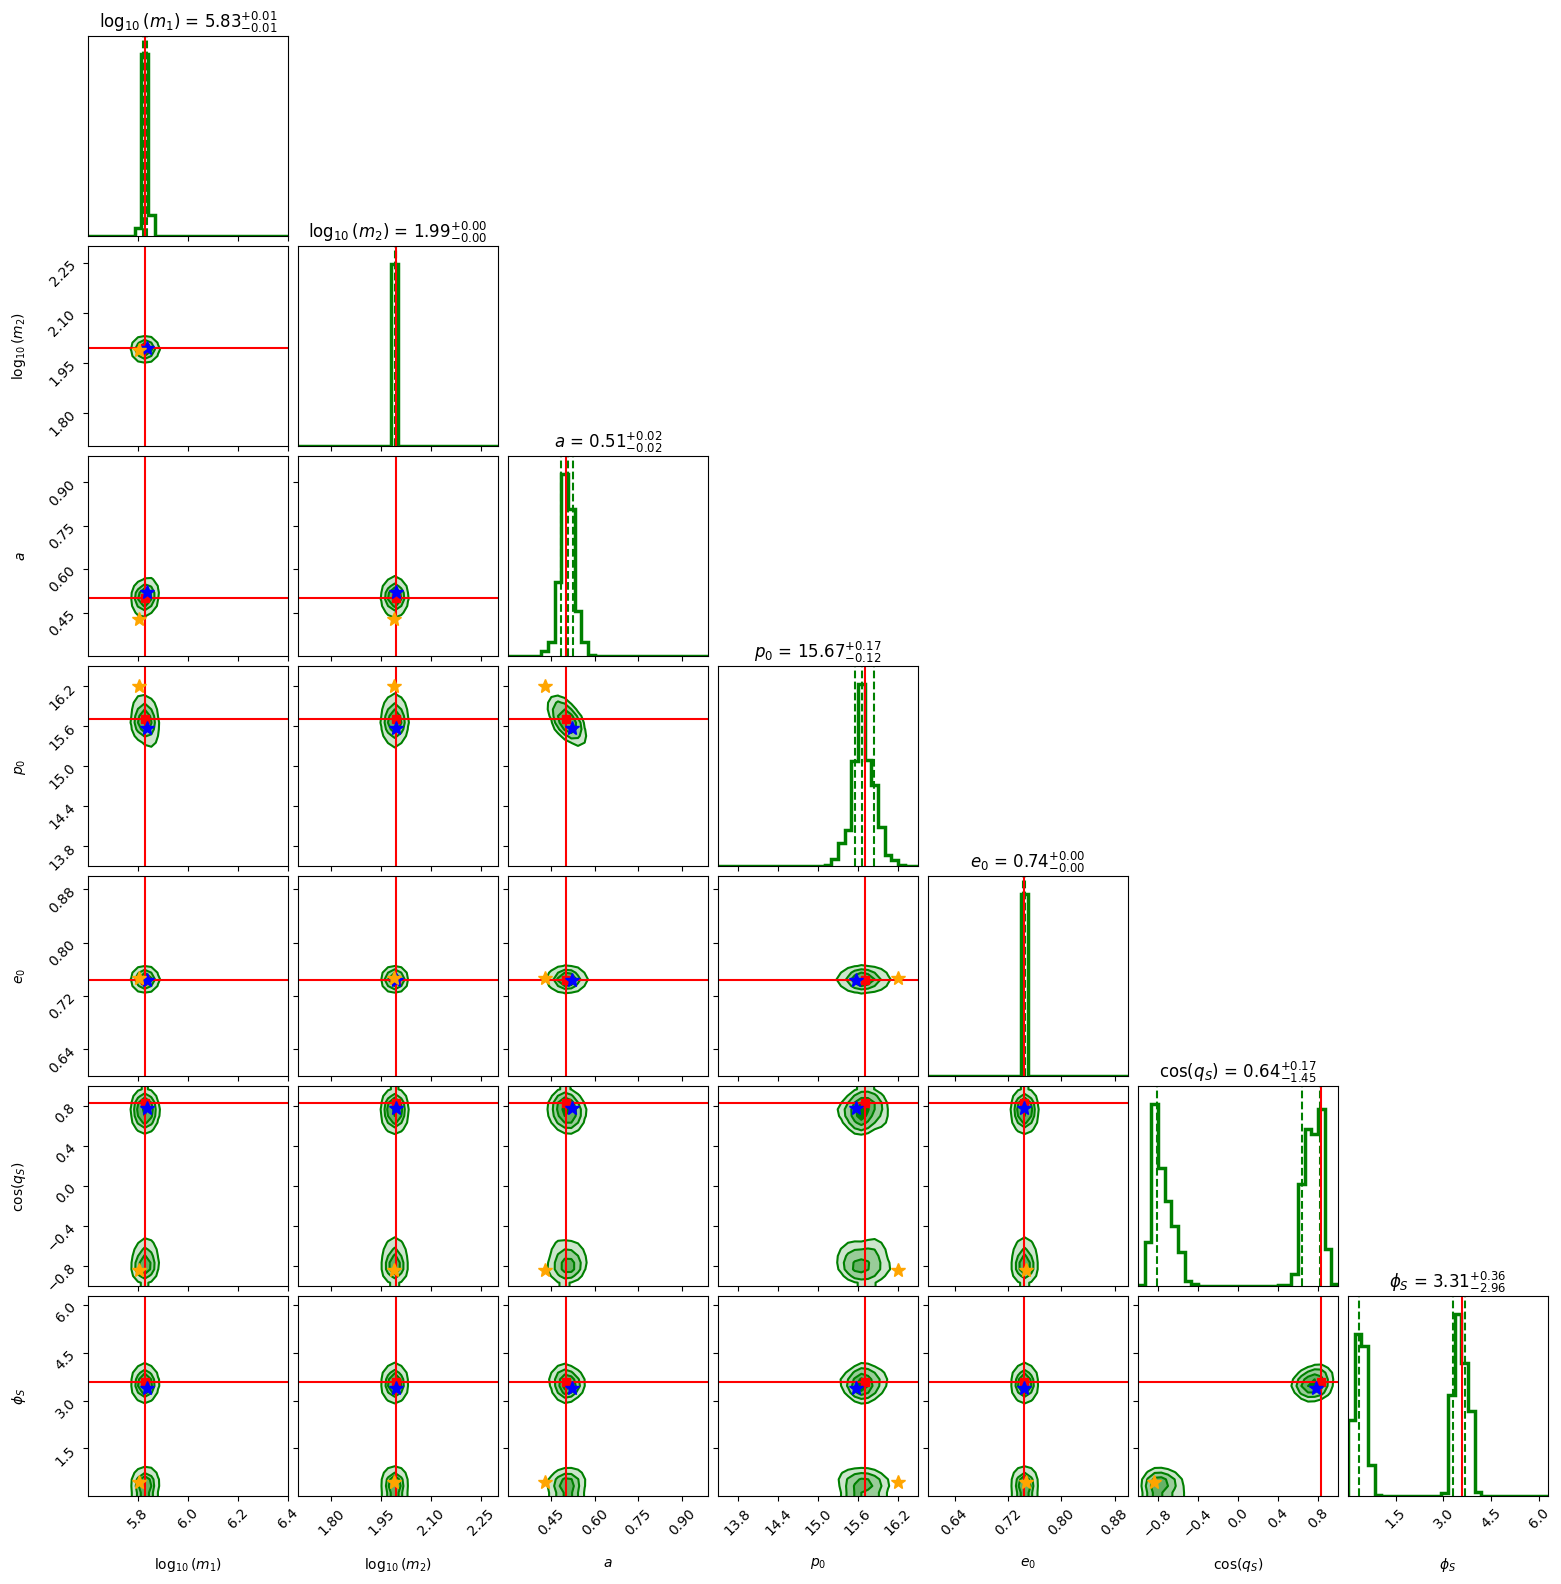

In [15]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)



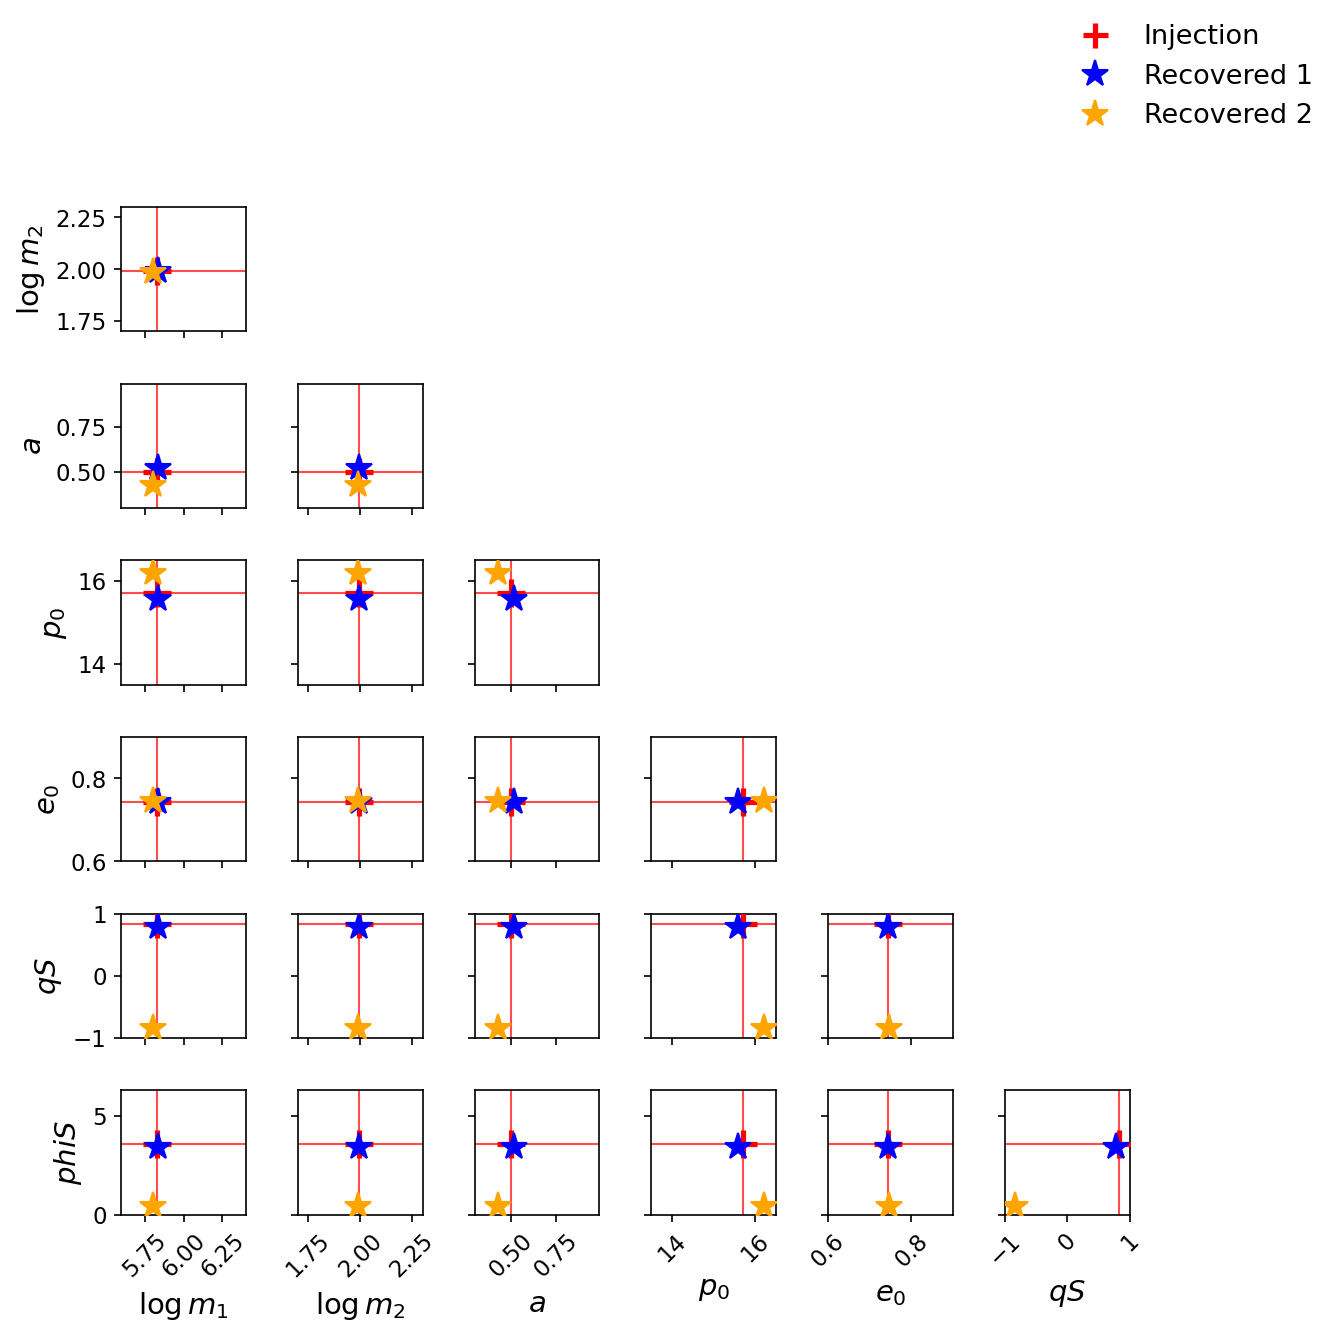

In [16]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
# maxld_pt3  = np.asarray(maxld_pt3).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # recovered MAP point
        # ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
        #         ms=13, zorder=4)
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    # Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [17]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.83423876,  1.99380873,  0.51982598, 15.57711103,  0.74333545,
         0.77934556,  3.39735454]])

In [18]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [19]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [20]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


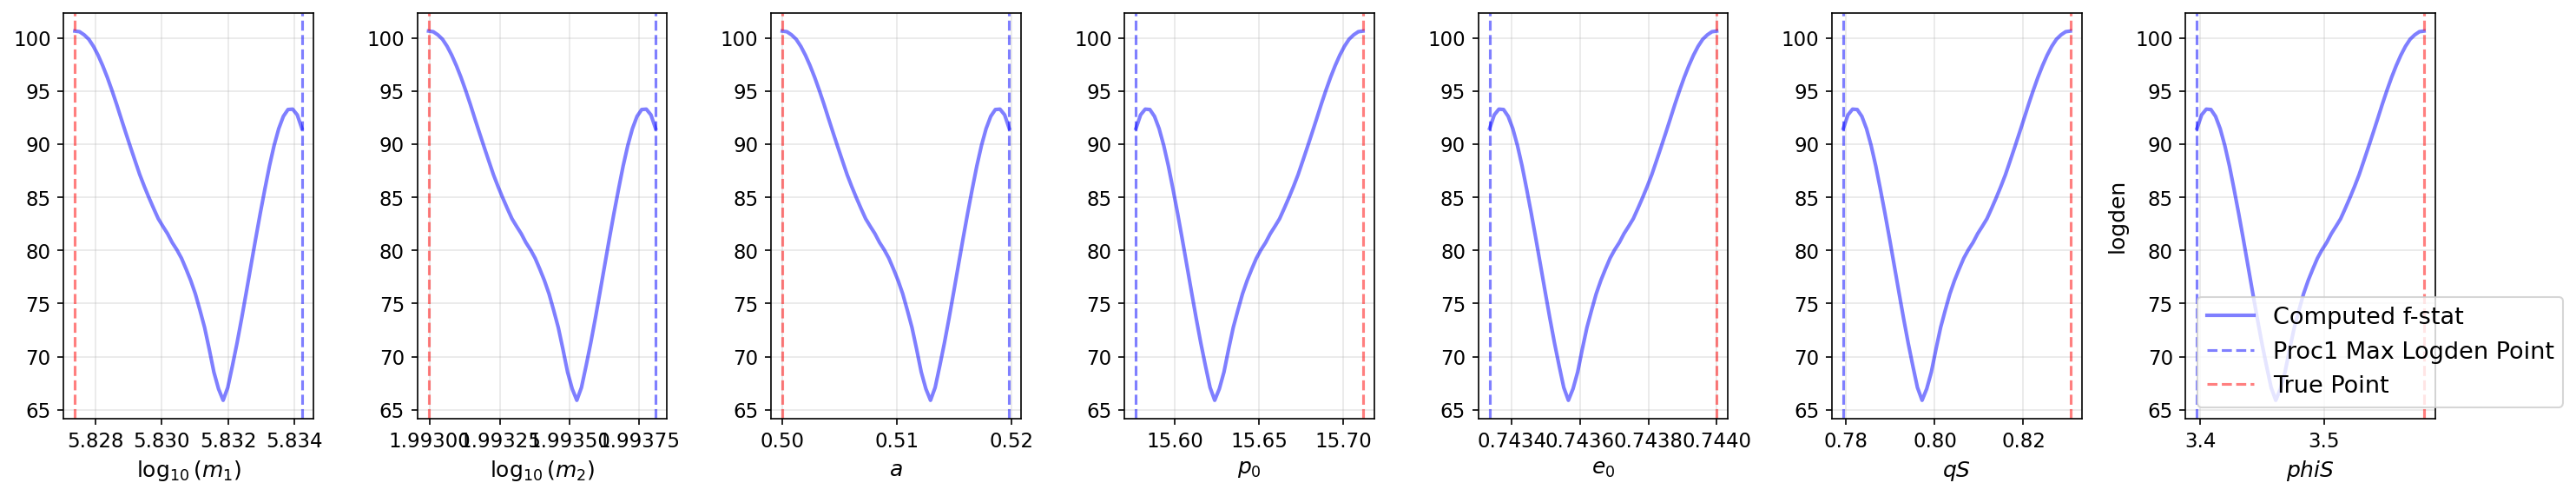

In [21]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


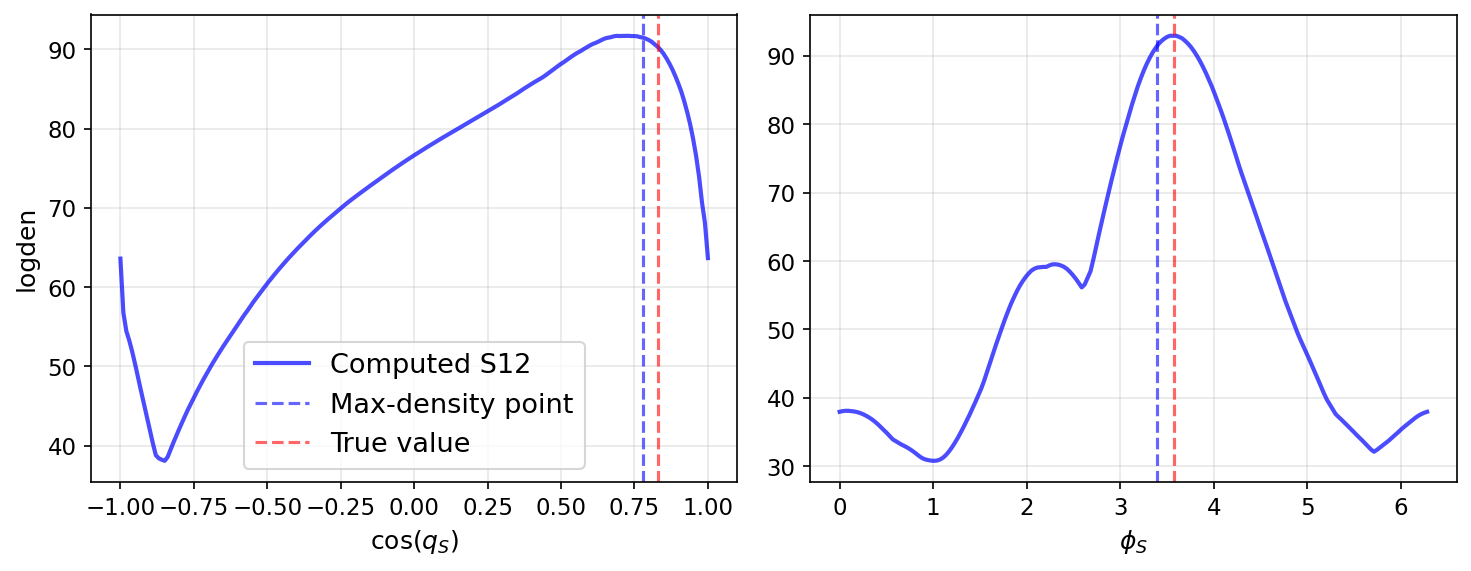

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# indices in the 12-dim brute param vector:
# [logm1, logm2, a, p0, e0, dist, cos_qS, phiS, cos_qK, phiK, Phi_phi0, Phi_r0]
sky_dims = {
    r'$\cos(q_S)$': (5, param_ranges[5]),
    r'$\phi_S$':    (6, param_ranges[6]),
}

n_grid = 200
fig, axes = plt.subplots(1, len(sky_dims), figsize=(10, 4))

for ax, (label, (dim_idx, lim)) in zip(axes, sky_dims.items()):
    lo, hi = lim
    grid_vals = np.linspace(lo, hi, n_grid)

    scan_pts = np.tile(proc1_maxld_pt_1d, (n_grid, 1))
    scan_pts[:, dim_idx] = grid_vals

    logden_scan = log_density(scan_pts)

    ax.plot(grid_vals, logden_scan, '-', color='blue', alpha=0.7, linewidth=2, label='Computed S12')
    ax.axvline(proc1_maxld_pt_1d[dim_idx], color='blue', linestyle='--', alpha=0.6, label='Max-density point')
    ax.axvline(param_true[dim_idx], color='red', linestyle='--', alpha=0.6, label='True value')
    ax.set_xlabel(label, fontsize=12)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('logden', fontsize=12)
axes[0].legend()
fig.tight_layout()